# HW2 - Clustering approach // 2K-means

## Methodology

**Preprocessing:**  
- We don't standardize the data because the features are Principal Components where variance is important information. Re-standardizing would scale low-variance ("noise") components to the same level as high-variance ("main info") components. 

**Clustering method Choice:**
- Using **K-means** algo because the dataset consists of continuous variables, for which K-means is generally preferred + computationally efficient (Cf cours p36). We will use the built-in function as used in code replication [29].  
- Elbow method to determine the appropriate number of clusters $K$ : We use the K-means algorithm for several numbers of clusters and save the squared distance given by the optimal partitions inside a list. We then plot the list and chose the $K$ that returns the leftmost elbow point.
- Running the algorithm multiple times for stability: after choosing K, since K-means is a stochastic algorithm (Cf p54), to ensure we find the global optimum rather than a local one, we run it 100 times (> recommended 20 cf p49) using the 'n_init' argument of the built-in function. The function will then automatically select the output with the lowest sum of squared distances.


## Code

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Loading the data
file_path = '/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW2 - Clustering/Cancer_gene_PCA.csv'
data = pd.read_csv(file_path, index_col=0)
print(data.head())

          feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
sample_0 -10.672635   2.668259  -1.384251 -10.682740  -0.212958  -1.338229   
sample_1  -2.899808   0.962219  -0.069269  10.066014  -0.534312  -0.042701   
sample_2 -11.967756  -0.267833  -1.241845 -12.414569   0.026778   9.284769   
sample_3  -1.058504  -2.859168  -1.406883  -5.683812  -0.683248   9.391650   
sample_5  -2.669765  -0.846943  -0.815662  -5.146322  -1.159697   6.902749   

          feature_6  feature_7  feature_8  feature_9  ...  feature_441  \
sample_0  -3.656913   0.123399  -1.396914   1.167158  ...    -0.234043   
sample_1  -5.308788  -9.289079  -0.018186 -16.889634  ...    -0.167138   
sample_2   7.131435   2.495428   1.656062   4.586602  ...    -8.965275   
sample_3 -10.937504   8.796449  -0.676974  -5.929782  ...    13.673321   
sample_5   4.848217  -4.643740   1.245135   3.469942  ...    -6.013867   

          feature_442  feature_443  feature_444  feature_445  feature_446  \
sample_0 

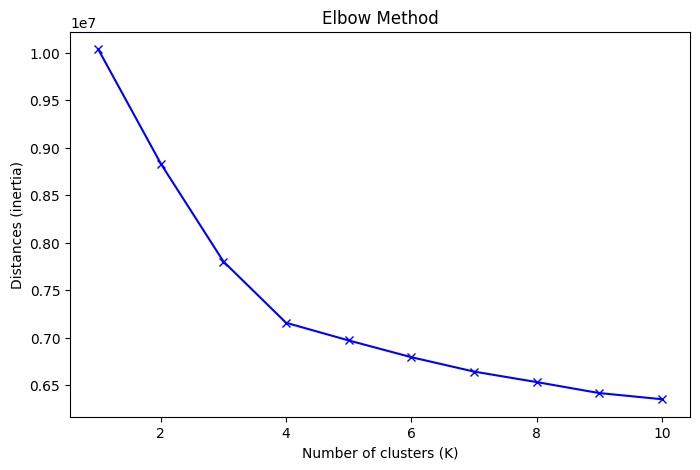

In [ ]:
# Determining Optimal K (Elbow Method) = Hyperparameter Tuning
distances = []               # list of squared distance for each given number of cluster // inertia=intra-cluster sum of squares.
K_range = range(1, 11)       # cluster nb

for k in K_range:
    # runs the algorithm n_init=10 times and only keeps the best model's inertia to append to the list. helps ensure graph is reliable (avoid local minima)
    kmeans = KMeans(n_clusters=k, random_state=23, n_init=10)
    kmeans.fit(data) # Fit the chosen model on the raw data  
    distances.append(kmeans.inertia_)

# Plotting the list
plt.figure(figsize=(8, 5))
plt.plot(K_range, distances, 'bx-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Distances (inertia)')
plt.title('Elbow Method')
plt.show()


Cf p47 "We plot the sum of squared distances against the number of clusters $K$ and select the number of clusters corresponding to the leftmost "elbow" point" ie where the graph bends and the reduction in variance begins to plateau."

Here, we chose $K = 4$

In [ ]:
# Clustering
k_optimal = 4   # after seeing the plot
model = KMeans(n_clusters=k_optimal, random_state=42, n_init=100)     # the function runs the algo 50 times (> recommended 20 cf cours) for k=4 and keeps the specific model that has the lowest inertia
data['Cluster_Label'] = model.fit_predict(data)     # output



## Analysis

In [4]:
# Silhouette score 
from sklearn.metrics import  silhouette_score
sil = silhouette_score(data.iloc[:,:-1], data['Cluster_Label'])
print(f"Silhouette score: {sil:.4f}")

Silhouette score: 0.1842


This silhouette score was close to, but better than, the one achieved using Hierarchical clustering (found K=4 also).

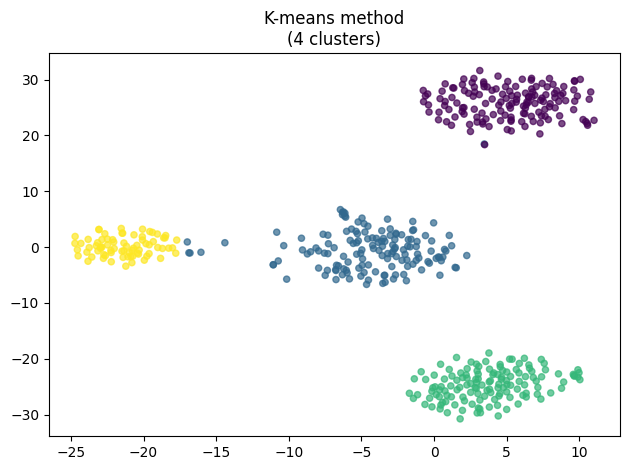

In [ ]:
# This plot was done using genAI help :)

from sklearn.manifold import TSNE
import numpy as np


X = data.iloc[:,:-1].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')   # """plot of reduced dimension.. Projects high-dimensional PCA data into 2D latent space""" 
X_embedded = tsne.fit_transform(X)
labels = data['Cluster_Label']
n_clusters = len(np.unique(labels))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='viridis', s=20, alpha=0.7)
plt.title(f"K-means method\n({n_clusters} clusters)")

plt.tight_layout()
plt.show()

Not too bad

## Export

In [5]:
# Export predictions 
# where my_predictions is a NumPy array or list containing cluster labels
data['Cluster_Label'].to_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW2 - Clustering/predictions2.csv', header=False, index=False)